In [11]:
import porespy as ps
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

Current working directory: /Users/lruepke/HydrothermalFoam_run/Spheres/phi_05/geometry
Porosity: 0.558


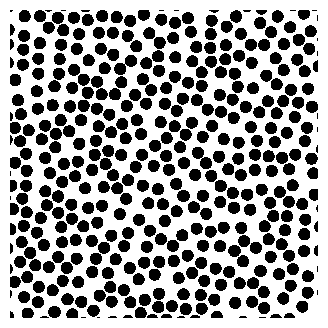

In [63]:
# 1. create a random sphere model using porespy

# show working directory
print(f"Current working directory: {os.getcwd()}")

shape           = [1256, 1256]      # size of the image in pixels
volume_fraction = 1               # approximately 1-porosity depending on radius and the boundary conditions
edges           = 'extended'        # 'extended' means that the spheres can extend beyond the image boundaries
clearance       = 10               # minimum distance between spheres in pixels
r               = 25                # radius of the spheres in same units as the image

# 2. generate the spheres and show / ~ to stay with earlier convention that black is solid
im = ~ps.generators.random_spheres(im_or_shape=shape, r=r, clearance=clearance, volume_fraction=volume_fraction, edges=edges)
fig, ax = plt.subplots(1, 1, figsize=[4, 4])
ax.axis(False) # turn off decoration
ax.imshow(im, origin='lower', interpolation='none', cmap='gray');

# sum pixel>1/total pixels
print(f"Porosity: {np.sum(im > 0) / np.prod(shape):.3f}")



In [57]:
# 3. save as vti (VTK's image format)

arr = np.asarray(im, dtype=int)*255  # convert to int and scale to 0-255 for VTK

# 3.1 make 3D by repeating in new axis=2 dimension (openfoam and porespy want 3D)
arr_stacked = np.stack((arr,arr), axis=2)

# 3.2 save as vti using porespy
print('Saving as vti...')   
ps.io.to_vtk(arr_stacked, 'porous_model_spheres')

# save arr as png
print('Saving as png...')
im_pil = Image.fromarray(arr.astype(np.uint8))  # convert to PIL image
im_pil.save('porous_model_spheres.png')

Saving as vti...
Saving as png...
